**Norm-fix rerun** of `wrappers/qwen_analysis/grid/1_loudest_layer/qwen_p2_grid_loudest_layer.ipynb` (Qwen final norm `1 + w`). Substitutions: `Path("/workspace/loudness_evaluation/qwen_p2_grid_layer_profile")` → `Path("/workspace/loudness_evaluation/qwen_p2_grid_layer_profile_fixnorm")`

# Qwen P2 — grid loudness per layer

Which layer is most **grid**-loaded, over the whole training set. The answer should pin
`--select-candidate-layers` (`LAYER`) in `grid/2_dataset_creation/1_p2_selection/`, which currently
inherits 27 from the direction line.

Input is what `wrappers/qwen_analysis/grid/1_loudest_layer/join_loudness_profile.sh` writes: one
row per reasoning token, one `L{layer}` column per layer, each cell `log P(any grid word)` at
that (token, layer), over the pruned Qwen grid vocabulary.

An **empty** cell means the lens did not cover that layer (the jlens outside its fitted
range) — not "no mass here". It becomes `NaN` and is skipped by the mean.

Most grid mass is AXIS (row/column words; see `data/jlens/README.md`), so a peak here is
largely a coordinate-bookkeeping peak.

In [1]:
# 1. imports and load the joined tables
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

OUT_DIR = Path("/workspace/loudness_evaluation/qwen_p2_grid_layer_profile_fixnorm")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# keep_default_na=False: decoded tokens include the literal string "NA" and empty
# strings, which pandas would otherwise turn into missing values.
jlens = pd.read_csv(OUT_DIR / "jlens_tokens.csv", keep_default_na=False, low_memory=False)
logitlens = pd.read_csv(OUT_DIR / "logitlens_tokens.csv", keep_default_na=False, low_memory=False)

print(f"jlens:     {len(jlens):,} token rows, {jlens.trajectory.nunique():,} trajectories")
print(f"logitlens: {len(logitlens):,} token rows, {logitlens.trajectory.nunique():,} trajectories")
jlens.head()

jlens:     460,484 token rows, 549 trajectories
logitlens: 460,484 token rows, 549 trajectories


,trajectory,size,complexity,run,step,reasoning_pos,abs_pos,token,agent_action,L3,L7,L11,L15,L19,L23,L27,L31,L35,L39
0,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,4,551,Ġto,DOWN,-5.272492,-5.047831,-5.050134,-4.603145,-3.110601,-2.582462,-4.054346,-5.449710,-10.002724,-11.406846
1,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,55,602,).,DOWN,-10.719273,-7.534753,-4.407144,-2.873886,-1.264450,-0.684168,-1.010070,-2.443462,-8.386615,-12.143424
2,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,113,660,#,DOWN,-0.000793,-0.001238,-0.000265,-0.003336,-0.007986,-0.010624,-0.413752,-1.133609,-0.694126,-0.000004
3,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,131,678,#,DOWN,-0.000736,-0.000618,-0.000202,-0.001463,-0.005251,-0.013861,-0.154291,-0.495473,-0.385866,0.000000
4,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,143,690,Ċ,DOWN,-4.028700,-3.667142,-2.126626,-0.751968,-1.378172,-0.454557,-0.094080,-0.047433,-0.000048,0.000000


In [2]:
# 2. aggregate at row level — every token is one observation
def layer_columns(df):
    """The L{layer} columns, in layer order."""
    cols = [c for c in df.columns if c.startswith("L") and c[1:].isdigit()]
    return sorted(cols, key=lambda c: int(c[1:]))


def loudness_matrix(df):
    """Just the layer columns, numeric. Empty cells (layer not covered) become NaN."""
    cols = layer_columns(df)
    return df[cols].apply(pd.to_numeric, errors="coerce")


jlens_mass = loudness_matrix(jlens)
logitlens_mass = loudness_matrix(logitlens)

print("layers:", [int(c[1:]) for c in layer_columns(jlens)])
print(f"jlens rows: {len(jlens_mass):,}   logitlens rows: {len(logitlens_mass):,}")

layers: [3, 7, 11, 15, 19, 23, 27, 31, 35, 39]
jlens rows: 460,484   logitlens rows: 460,484


In [3]:
# 3. mean grid loudness per layer
def mean_per_layer(mass):
    """{layer: mean loudness}, as a Series indexed by integer layer."""
    means = mass.mean()  # skips NaN
    means.index = [int(c[1:]) for c in means.index]
    return means.sort_index()


jlens_per_layer = mean_per_layer(jlens_mass)
logitlens_per_layer = mean_per_layer(logitlens_mass)

print(f"jlens argmax layer:     {jlens_per_layer.idxmax()}  ({jlens_per_layer.max():.4f})")
print(f"logitlens argmax layer: {logitlens_per_layer.idxmax()}  ({logitlens_per_layer.max():.4f})")
pd.DataFrame({"jlens": jlens_per_layer, "logitlens": logitlens_per_layer})

jlens argmax layer:     27  (-4.1233)
logitlens argmax layer: 2  (-5.7728)


,jlens,logitlens
0,NaN,-5.910975
1,NaN,-5.880880
2,NaN,-5.772841
3,-7.225604,-6.029259
4,NaN,-6.037238
5,NaN,-5.967132
6,NaN,-5.995360
7,-6.522457,-5.879939
8,NaN,-5.923443
9,NaN,-5.998024


saved /workspace/loudness_evaluation/qwen_p2_grid_layer_profile_fixnorm/figures/jlens_loudness_per_layer.png


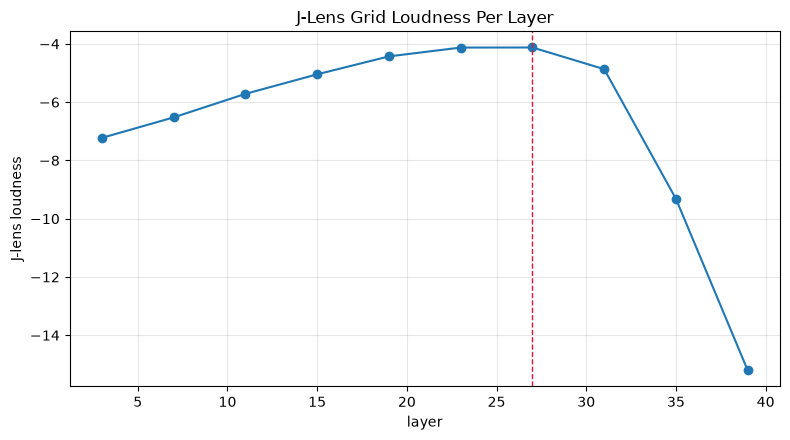

In [4]:
# 4. J-Lens Grid Loudness Per Layer
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(jlens_per_layer.index, jlens_per_layer.values, marker="o")
ax.axvline(jlens_per_layer.idxmax(), color="crimson", linestyle="--", linewidth=1)
ax.set_title("J-Lens Grid Loudness Per Layer")
ax.set_xlabel("layer")
ax.set_ylabel("J-lens loudness")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "jlens_loudness_per_layer.png", dpi=160, bbox_inches="tight")
print("saved", FIG_DIR / "jlens_loudness_per_layer.png")
plt.show()

saved /workspace/loudness_evaluation/qwen_p2_grid_layer_profile_fixnorm/figures/logitlens_loudness_per_layer.png


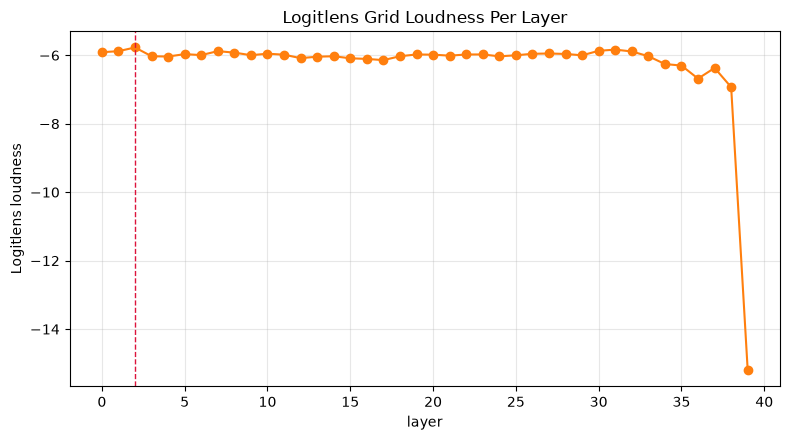

In [5]:
# 5. Logitlens Grid Loudness Per Layer
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(logitlens_per_layer.index, logitlens_per_layer.values, marker="o", color="tab:orange")
ax.axvline(logitlens_per_layer.idxmax(), color="crimson", linestyle="--", linewidth=1)
ax.set_title("Logitlens Grid Loudness Per Layer")
ax.set_xlabel("layer")
ax.set_ylabel("Logitlens loudness")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "logitlens_loudness_per_layer.png", dpi=160, bbox_inches="tight")
print("saved", FIG_DIR / "logitlens_loudness_per_layer.png")
plt.show()